In [22]:
import numpy as np
import matplotlib.pyplot as plt
# import sympy as smp
import scienceplots
plt.style.use('science')

plt.rcParams.update({
    'font.size': 15,
    'axes.labelsize': 25,
    'axes.titlesize': 16,
    'legend.fontsize': 12,
    'axes.labelweight': 'bold',
    'font.weight': 'bold',
    'font.family': 'sans-serif',})

# Results and Plots

In [3]:
fh = open("data.txt", "r")
data = np.array([list(map(float, line.split())) for line in fh.readlines()])
fh.close()

In [4]:
grayscale = data[:, 0]
delta = data[:, 1]
psi = data[:, 2]

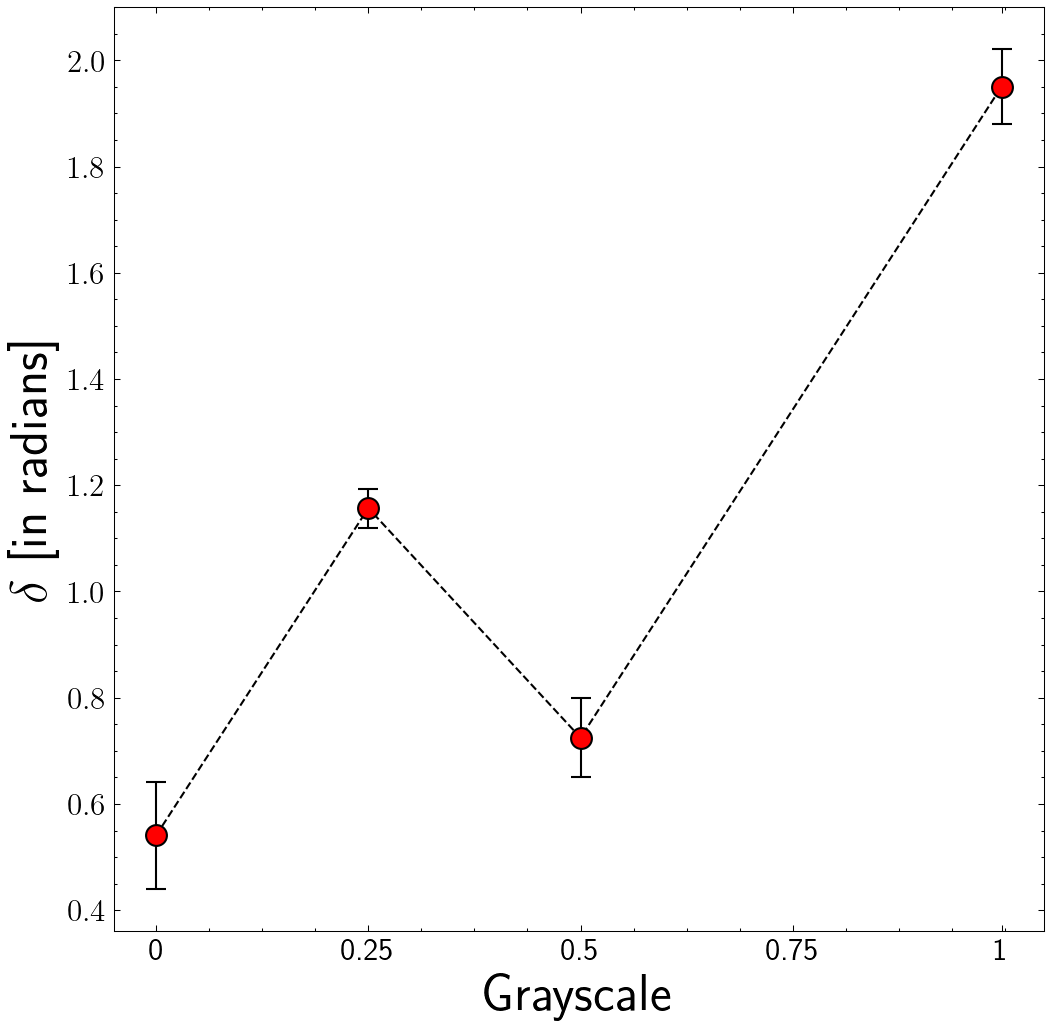

In [37]:
fig, ax = plt.subplots(1, 1, dpi=150, figsize=(8, 8))
# [ax.set_xlabel("Grayscale") for ax in axes]
# ax = axes[0]
delterr = [0.10122603185647458,
 0.036590709202269665,
 0.07457134291927592,
 0.07065590126618339]
ax.set_xlabel("Grayscale")
ax.set_ylabel(r"$\delta$"+" [in radians]")
ax.plot(grayscale, delta, "k--")
ax.errorbar(grayscale, delta, yerr=delterr, fmt='o', color='k', capsize=5)
ax.scatter(grayscale, delta, color="r", s=100, edgecolor="k", zorder=3)
ax.set_xticks([0, 64, 128, 192, 255], [0, 0.25, 0.50, 0.75, 1]);
fig.savefig("../note/assets/linear_ret_err.png")

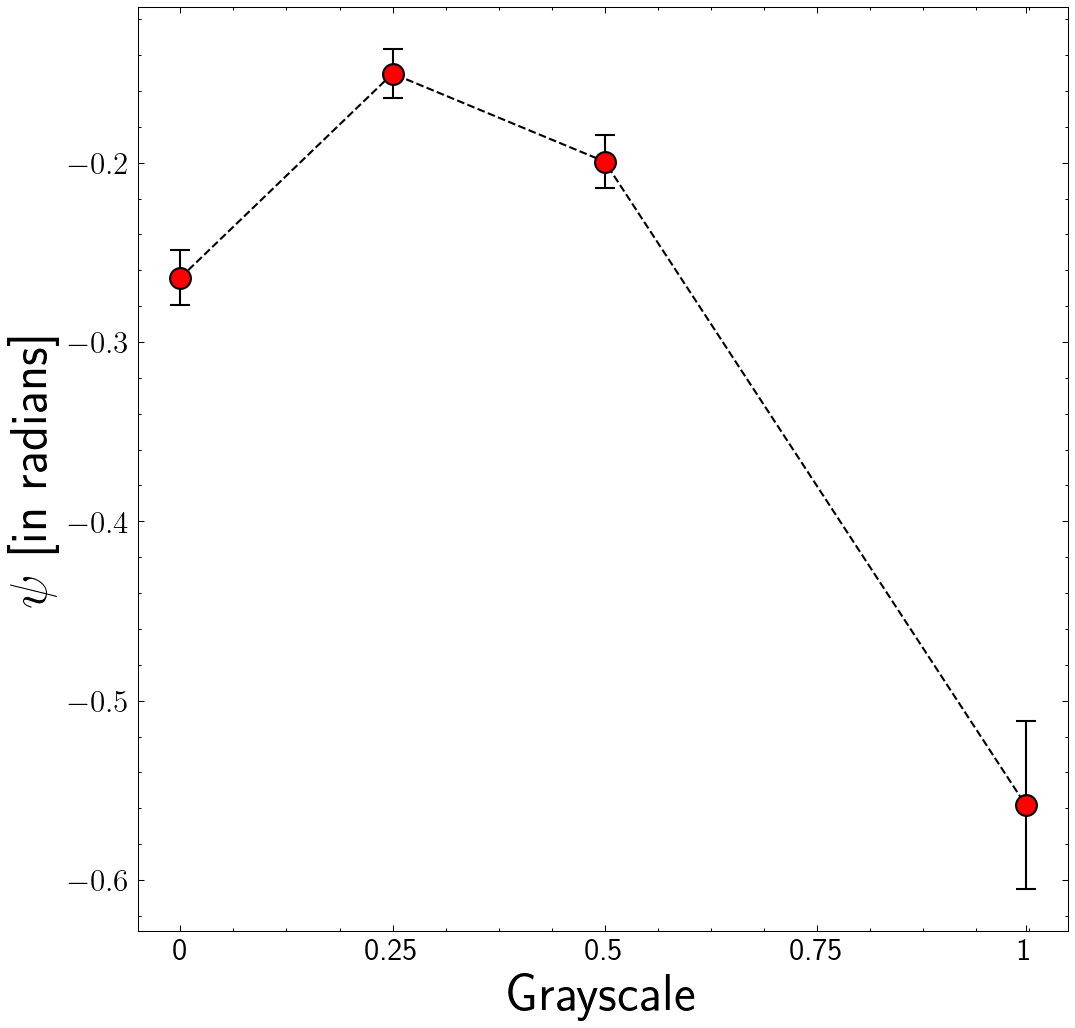

In [35]:
fig, ax = plt.subplots(1, 1, dpi=150, figsize=(8, 8))
# [ax.set_xlabel("Grayscale") for ax in axes]
# ax = axes[0]
ax.set_xlabel("Grayscale")
psierr = [0.01535436589285946,
 0.013676804694927462,
 0.014883035902521644,
 0.04676578190765936]
ax.errorbar(grayscale, psi, yerr=psierr, fmt='o', color='k', capsize=5)
ax.set_ylabel(r"$\psi$"+" [in radians]")
ax.plot(grayscale, psi, "k--")
ax.scatter(grayscale, psi, color="r", s=100, edgecolor="k", zorder=3)
ax.set_xticks([0, 64, 128, 192, 255], [0, 0.25, 0.50, 0.75, 1])
fig.savefig("../note/assets/optical_rotation_err.png")

# Error Analysis (Error Propagation)

In [6]:
H_H, V_H, P_H, M_H = smp.symbols("H_H V_H P_H M_H", real=True)
H_P, V_P, P_P, M_P = smp.symbols("H_P V_P P_P M_P", real=True)
I_H, Q_H, U_H, V_H = smp.symbols("I_H Q_H U_H V_H", real=True)
I_P, Q_P, U_P, V_P = smp.symbols("I_P Q_P U_P V_P", real=True)
X, Y = smp.symbols("X Y", real=True)
delta, psi = smp.symbols("delta psi", real=True)

In [7]:
delta = smp.acos(smp.sqrt(X**2 + Y**2) - 1)
psi = 1/2 * smp.atan(Y/X)

In [8]:
X_expr = (H_H - V_H)/(H_H + V_H) + (-M_P + P_P)/(H_P + V_P)
Y_expr = -(H_P - V_P)/(H_P + V_P) + (-M_H + P_H)/(H_H + V_H)
subs_dict = {
    X: X_expr,
    Y: Y_expr
}

dDeltadX = smp.diff(delta, X).subs(subs_dict)
dDeltadY = smp.diff(delta, Y).subs(subs_dict)
dPsidX = smp.diff(psi, X).subs(subs_dict)
dPsidY = smp.diff(psi, Y).subs(subs_dict)

In [9]:
ddxDelta = smp.lambdify((X, Y), dDeltadX)
ddyDelta = smp.lambdify((X, Y), dDeltadY)
ddxPsi = smp.lambdify((X, Y), dPsidX)
ddyPsi = smp.lambdify((X, Y), dPsidY)

In [10]:
X = Q_H + U_P
Y = U_H - Q_P

In [11]:
dXdQH = smp.diff(X, Q_H)
dXdUP = smp.diff(X, U_P)
dYdUH = smp.diff(Y, U_H)
dYdQP = smp.diff(Y, Q_P)

In [12]:
I_H = H_H + V_H
Q_H = (H_H - V_H)/I_H
U_H = (P_H - M_H)/I_H
I_P = H_P + V_P
Q_P = (H_P - V_P)/I_P
U_P = (P_P - M_P)/I_P

In [13]:
dQdH = smp.diff(Q_H, H_H)
dQdV = smp.diff(Q_H, V_H)
dUdP = smp.diff(U_H, P_H)
dUdM = smp.diff(U_H, M_H)
dUdH = smp.diff(U_H, H_H)
dUdV = smp.diff(U_H, V_H)
dQdH_P = smp.diff(Q_P, H_P)
dQdV_P = smp.diff(Q_P, V_P)
dUdP_P = smp.diff(U_P, P_P)
dUdM_P = smp.diff(U_P, M_P)
dUdH_P = smp.diff(U_P, H_P)
dUdV_P = smp.diff(U_P, V_P)

In [14]:
delta_X, delta_Y, delta_Q, delta_U, delta_H, delta_V, delta_P, delta_M = smp.symbols("delta_X delta_Y delta_Q delta_U delta_H delta_V delta_P delta_M", real=True)

In [15]:
delta_Q = smp.Abs(dQdH)*delta_H + smp.Abs(dQdV)*delta_V
delta_U = smp.Abs(dUdH)*delta_H + smp.Abs(dUdV)*delta_V + smp.Abs(dUdP)*delta_P + smp.Abs(dUdM)*delta_M
delta_Q_P =smp.Abs(dQdH_P)*delta_H + smp.Abs(dQdV_P)*delta_V
delta_U_P = smp.Abs(dUdH_P)*delta_H + smp.Abs(dUdV_P)*delta_V + smp.Abs(dUdP_P)*delta_P + smp.Abs(dUdM_P)*delta_M
delta_X = smp.Abs(dXdQH)*delta_Q + smp.Abs(dXdUP)*delta_U_P
delta_Y = smp.Abs(dYdUH)*delta_U + smp.Abs(dYdQP)*delta_Q_P

In [16]:
delta_delta = (smp.Abs(dDeltadX)*delta_X + smp.Abs(dDeltadY)*delta_Y).simplify()
delta_psi = (smp.Abs(dPsidX)*delta_X + smp.Abs(dPsidY)*delta_Y).simplify()

In [17]:
delta_delta

((delta_M + delta_P + (2*delta_H*Abs(V_H/(H_H + V_H)**2) + delta_H*Abs((M_P - P_P)/(H_P + V_P)**2) + 2*delta_V*Abs(H_H/(H_H + V_H)**2) + delta_V*Abs((M_P - P_P)/(H_P + V_P)**2))*Abs(H_P + V_P))*Abs(((H_H - V_H)*(H_P + V_P) - (H_H + V_H)*(M_P - P_P))/(H_P + V_P)) + (delta_M + delta_P + (2*delta_H*Abs(V_P/(H_P + V_P)**2) + delta_H*Abs((M_H - P_H)/(H_H + V_H)**2) + 2*delta_V*Abs(H_P/(H_P + V_P)**2) + delta_V*Abs((M_H - P_H)/(H_H + V_H)**2))*Abs(H_H + V_H))*Abs(((H_H + V_H)*(H_P - V_P) + (H_P + V_P)*(M_H - P_H))/(H_H + V_H)))*Abs(1/(sqrt(1/((H_H + V_H)**2*(H_P + V_P)**2))*sqrt(1 - (sqrt(1/((H_H + V_H)**2*(H_P + V_P)**2))*sqrt(((H_H - V_H)*(H_P + V_P) + (H_H + V_H)*(-M_P + P_P))**2 + ((H_H + V_H)*(-H_P + V_P) + (H_P + V_P)*(-M_H + P_H))**2) - 1)**2)*(H_H + V_H)*(H_P + V_P)))/sqrt(((H_H - V_H)*(H_P + V_P) - (H_H + V_H)*(M_P - P_P))**2 + ((H_H + V_H)*(H_P - V_P) + (H_P + V_P)*(M_H - P_H))**2)

In [18]:
delta_psi

0.5*((delta_M + delta_P + (2*delta_H*Abs(V_H/(H_H + V_H)**2) + delta_H*Abs((M_P - P_P)/(H_P + V_P)**2) + 2*delta_V*Abs(H_H/(H_H + V_H)**2) + delta_V*Abs((M_P - P_P)/(H_P + V_P)**2))*Abs(H_P + V_P))*Abs((H_H + V_H)**2*(H_P + V_P)*((H_H + V_H)*(H_P - V_P) + (H_P + V_P)*(M_H - P_H))) + (delta_M + delta_P + (2*delta_H*Abs(V_P/(H_P + V_P)**2) + delta_H*Abs((M_H - P_H)/(H_H + V_H)**2) + 2*delta_V*Abs(H_P/(H_P + V_P)**2) + delta_V*Abs((M_H - P_H)/(H_H + V_H)**2))*Abs(H_H + V_H))*Abs((H_H + V_H)*(H_P + V_P)**2*((H_H - V_H)*(H_P + V_P) - (H_H + V_H)*(M_P - P_P))))*Abs(1/((H_H + V_H)*(H_P + V_P)))/(((H_H - V_H)*(H_P + V_P) - (H_H + V_H)*(M_P - P_P))**2 + ((H_H + V_H)*(H_P - V_P) + (H_P + V_P)*(M_H - P_H))**2)

In [19]:
delta_err = smp.lambdify((H_H, V_H, P_H, M_H, H_P, V_P, P_P, M_P, delta_H, delta_V, delta_P, delta_M), delta_delta, modules=[{"Abs": np.abs, "sqrt": np.sqrt}, "numpy"])
psi_err = smp.lambdify((H_H, V_H, P_H, M_H, H_P, V_P, P_P, M_P, delta_H, delta_V, delta_P, delta_M), delta_psi, modules=[{"Abs": np.abs, "sqrt": np.sqrt}, "numpy"])

In [20]:
delta_delta.free_symbols

{H_H, H_P, M_H, M_P, P_H, P_P, V_H, V_P, delta_H, delta_M, delta_P, delta_V}

In [21]:
fh = open("output_intensities.txt", "r")
data2 = [tuple(map(float, line.split())) for line in fh.readlines()]
fh.close()
deltas = (0.1, 0.1, 0.1, 0.1)

In [22]:
delta_errors = [delta_err(*gv, *deltas) for gv in data2]
psi_errors = [psi_err(*gv, *deltas) for gv in data2]

In [23]:
delta_errors

[0.10122603185647458,
 0.036590709202269665,
 0.07457134291927592,
 0.07065590126618339]

In [24]:
psi_errors

[0.01535436589285946,
 0.013676804694927462,
 0.014883035902521644,
 0.04676578190765936]

In [25]:
[print(f"|{gv}|{delta_errors[i]:.3f}|{psi_errors[i]:.3f}|") for i,gv in enumerate([0, 0.25, 0.50, 1.0])]

|0|0.101|0.015|
|0.25|0.037|0.014|
|0.5|0.075|0.015|
|1.0|0.071|0.047|


[None, None, None, None]

| Grayscale | $\Delta_\delta$ | $\Delta_\psi$ | 
------------|-----------------|---------------|
|0|0.101|0.015|
|0.25|0.037|0.014|
|0.5|0.075|0.015|
|1.0|0.071|0.047|
